# Customer Intelligence System using Machine Learning

---

## Project Title

**Customer Intelligence System using Machine Learning**

---

## Objective

The primary objective of this project is to develop an end-to-end Customer Intelligence System using various Machine Learning techniques. The project aims to analyze socio-economic indicators of different countries, discover hidden patterns, classify countries based on economic development, and segment countries into meaningful groups for strategic decision-making.

The project uses supervised learning algorithms for prediction and unsupervised learning algorithms for segmentation.

---


In [1]:
# ==========================================================
# Importing Required Libraries
# ==========================================================

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use("ggplot")

# Set Seaborn theme
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


# Importing Dataset

In this section, we load the datasets into pandas DataFrames.

Two files are used:

- Country-data.csv
- data-dictionary.csv

The first dataset contains country information.

The second dataset contains the description of each feature.

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')
country_df = pd.read_csv("/content/drive/MyDrive/Country-data.csv")

dictionary_df = pd.read_csv("/content/drive/MyDrive/data-dictionary.csv")

print("Datasets Loaded Successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets Loaded Successfully.


In [4]:
# Display first five rows

country_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
# Dataset Shape

rows = country_df.shape[0]
columns = country_df.shape[1]

print("Number of Rows :", rows)
print("Number of Columns :", columns)

Number of Rows : 167
Number of Columns : 10


In [6]:
country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
# Display column names

print("Column Names:\n")

for column in country_df.columns:
    print(column)

Column Names:

country
child_mort
exports
health
imports
income
inflation
life_expec
total_fer
gdpp


# Data Quality Assessment  Part 2

Data quality assessment ensures that the dataset is suitable for machine learning.

We will check:

- Duplicate records
- Missing values
- Memory usage
- Unique values
- Summary statistics
- Categorical summary

In [8]:
# Count duplicate rows

duplicate_count = country_df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 0


In [9]:
# Missing Values

missing_values = country_df.isnull().sum()

missing_values

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


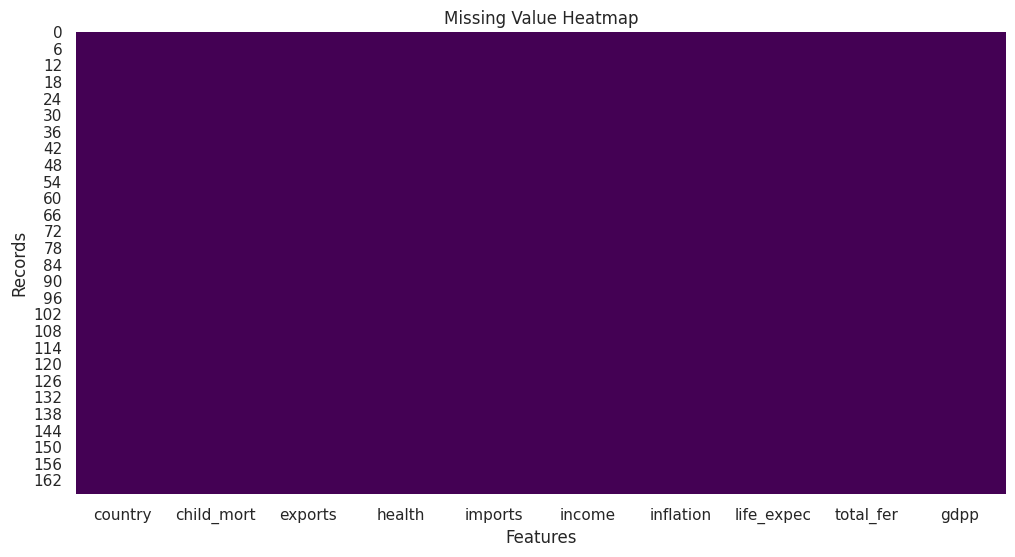

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(
    country_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.xlabel("Features")

plt.ylabel("Records")

plt.show()

In [11]:
for column in country_df.columns:

    print("-"*50)

    print("Column :", column)

    print("Unique Values :", country_df[column].nunique())

--------------------------------------------------
Column : country
Unique Values : 167
--------------------------------------------------
Column : child_mort
Unique Values : 139
--------------------------------------------------
Column : exports
Unique Values : 147
--------------------------------------------------
Column : health
Unique Values : 147
--------------------------------------------------
Column : imports
Unique Values : 151
--------------------------------------------------
Column : income
Unique Values : 156
--------------------------------------------------
Column : inflation
Unique Values : 156
--------------------------------------------------
Column : life_expec
Unique Values : 127
--------------------------------------------------
Column : total_fer
Unique Values : 138
--------------------------------------------------
Column : gdpp
Unique Values : 157


In [12]:
country_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# Observation

Summary statistics provide:

- Mean
- Median
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These statistics help identify skewness and potential outliers.

In [13]:
country_df.describe(include="object")

,country
count,167
unique,167
top,Afghanistan
freq,1


In [14]:
country_df["country"].value_counts()

,count
country,
Afghanistan,1
Albania,1
Algeria,1
Angola,1
Antigua and Barbuda,1
...,...
Vanuatu,1
Venezuela,1
Vietnam,1


# Exploratory Data Analysis (EDA)

## Introduction

Exploratory Data Analysis (EDA) is one of the most important phases of any Machine Learning project.

EDA helps us:

- Understand the distribution of data
- Detect outliers
- Find relationships between variables
- Identify trends and patterns
- Generate business insights
- Prepare the dataset for Machine Learning

In this section, we will perform multiple visualizations to better understand the socio-economic characteristics of different countries.

## Visualization 1: Child Mortality Distribution

Child mortality represents the number of deaths of children under the age of five.

Understanding its distribution helps identify countries facing serious healthcare challenges.

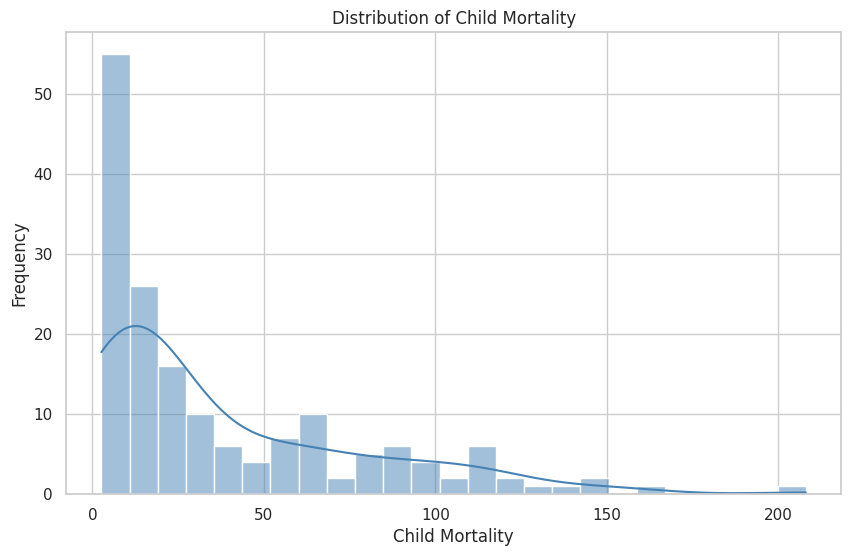

In [15]:
# ==========================================================
# Distribution Plot of Child Mortality
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=country_df,
    x="child_mort",
    bins=25,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Child Mortality")

plt.xlabel("Child Mortality")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Visualization 2: Income Distribution

Income is one of the strongest indicators of a country's economic development.

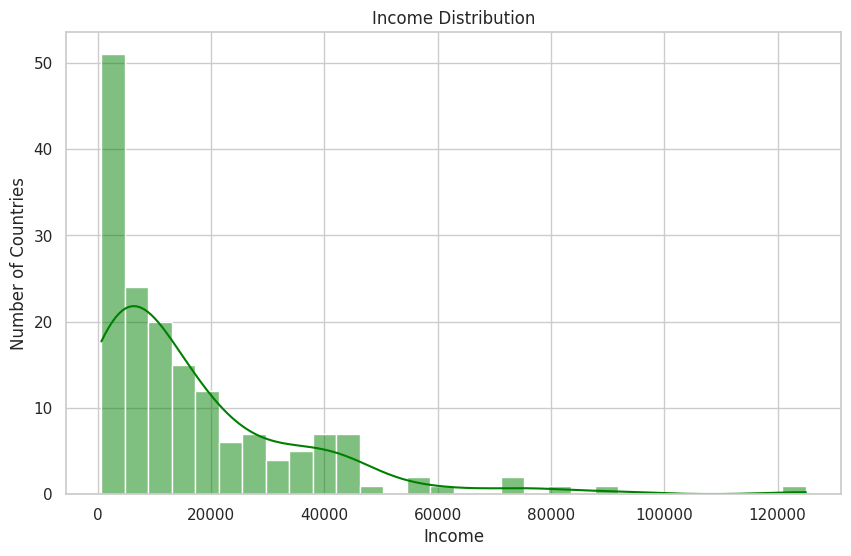

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=country_df,
    x="income",
    bins=30,
    kde=True,
    color="green"
)

plt.title("Income Distribution")

plt.xlabel("Income")

plt.ylabel("Number of Countries")

plt.grid(True)

plt.show()

## Visualization 3: GDP Per Capita Distribution

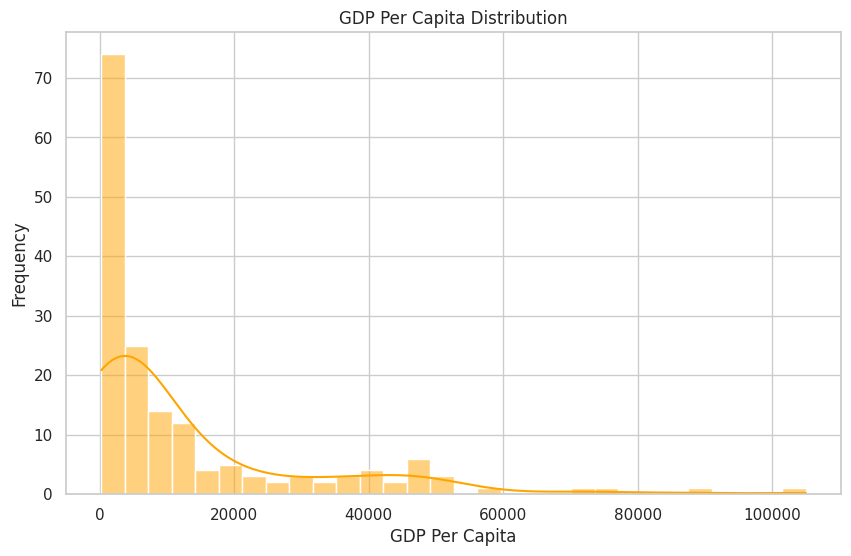

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    country_df["gdpp"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("GDP Per Capita Distribution")

plt.xlabel("GDP Per Capita")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Visualization 4: Detecting Outliers in GDP

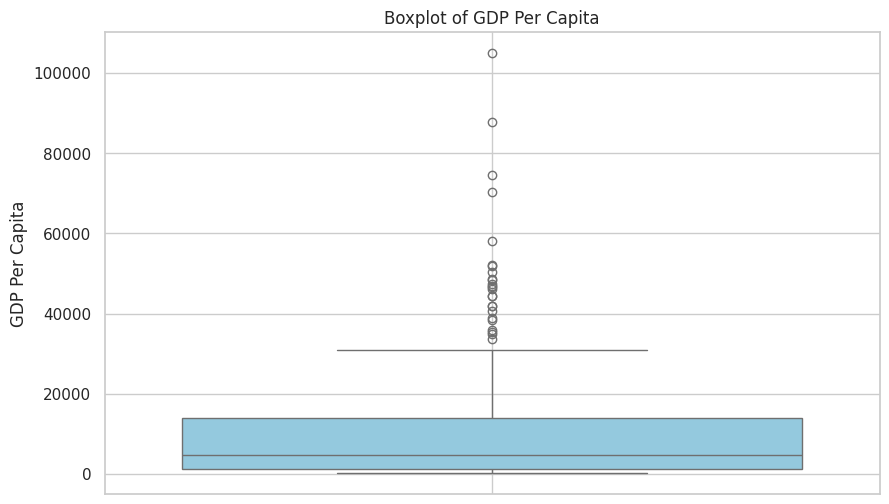

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=country_df["gdpp"],
    color="skyblue"
)

plt.title("Boxplot of GDP Per Capita")

plt.ylabel("GDP Per Capita")

plt.grid(True)

plt.show()

## Visualization 5: Healthcare Spending Distribution

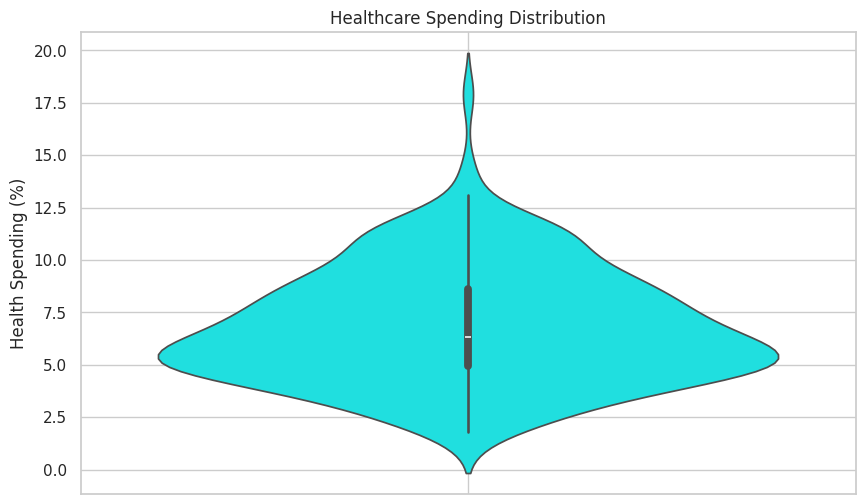

In [19]:
plt.figure(figsize=(10,6))

sns.violinplot(
    y=country_df["health"],
    color="cyan"
)

plt.title("Healthcare Spending Distribution")

plt.ylabel("Health Spending (%)")

plt.grid(True)

plt.show()

## Visualization 6: Correlation Heatmap

The correlation matrix helps identify relationships between numerical variables.

Positive values indicate a positive relationship.

Negative values indicate an inverse relationship.

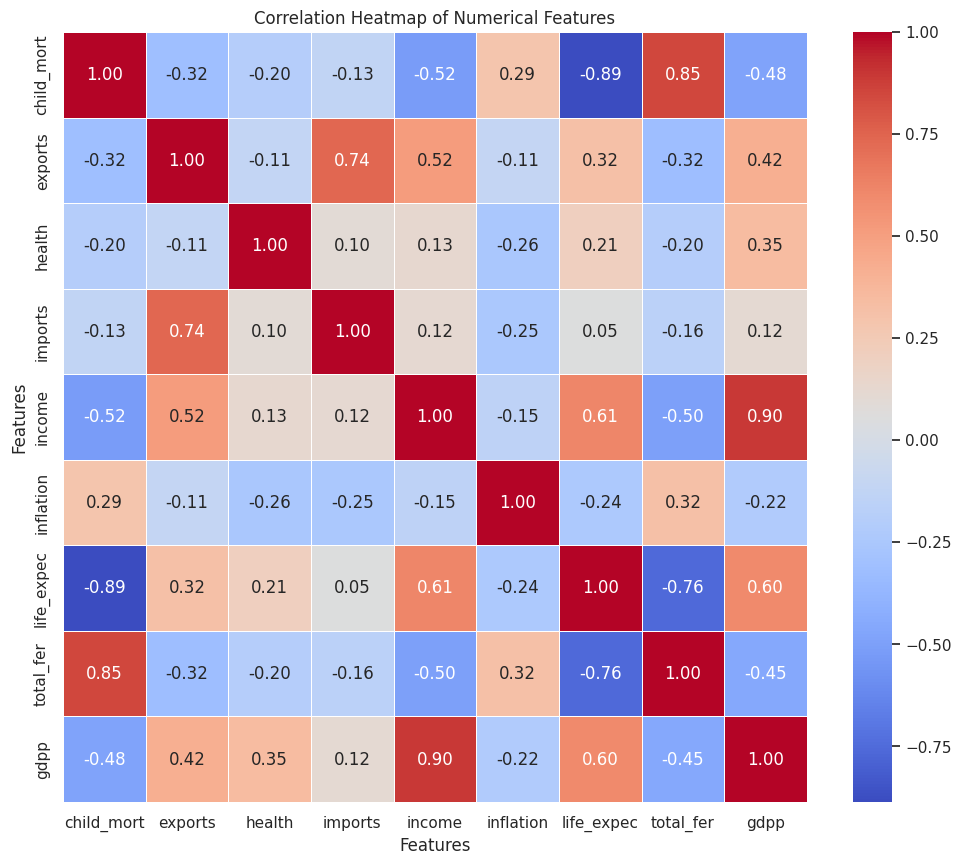

In [20]:
# ==========================================================
# Selecting Numerical Features
# ==========================================================

numerical_columns = country_df.select_dtypes(include=["int64", "float64"])

# ==========================================================
# Correlation Matrix
# ==========================================================

correlation_matrix = numerical_columns.corr()

# ==========================================================
# Plot Heatmap
# ==========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.xlabel("Features")

plt.ylabel("Features")

plt.show()

* Inferences

Income and GDP generally exhibit a strong positive correlation.
Child mortality tends to have a negative correlation with life expectancy.
Health expenditure often shows a positive association with life expectancy.
Correlation analysis helps identify influential features for future machine learning models.

# Strongest Positive Correlations

In [21]:
# ==========================================================
# Display Highly Positive Correlations
# ==========================================================

correlation_pairs = correlation_matrix.unstack()

correlation_pairs = correlation_pairs.sort_values(ascending=False)

positive_correlations = correlation_pairs[
    (correlation_pairs < 1.0) &
    (correlation_pairs > 0.70)
]

print("Highly Positive Correlations")

positive_correlations.drop_duplicates()

Highly Positive Correlations


,,0
income,gdpp,0.895571
total_fer,child_mort,0.848478
exports,imports,0.737381


# Strongest Negative Correlations

In [22]:
# ==========================================================
# Display Strong Negative Correlations
# ==========================================================

negative_correlations = correlation_pairs[
    correlation_pairs < -0.60
]

print("Highly Negative Correlations")

negative_correlations.drop_duplicates()

Highly Negative Correlations


,,0
total_fer,life_expec,-0.760875
child_mort,life_expec,-0.886676


# Standard Deviation of Features

In [23]:


standard_deviation = country_df.std(numeric_only=True)

standard_deviation

,0
child_mort,40.328931
exports,27.412010
health,2.746837
imports,24.209589
income,19278.067698
inflation,10.570704
life_expec,8.893172
total_fer,1.513848
gdpp,18328.704809


# Skewness Analysis

In [24]:
skewness = country_df.skew(numeric_only=True)

print(skewness)

child_mort    1.450774
exports       2.445824
health        0.705746
imports       1.905276
income        2.231480
inflation     5.154049
life_expec   -0.970996
total_fer     0.967092
gdpp          2.218051
dtype: float64


# Kurtosis Analysis

In [25]:
kurtosis_values = country_df.kurtosis(numeric_only=True)

print(kurtosis_values)

child_mort     1.766882
exports       10.138666
health         0.694196
imports        6.755854
income         7.028657
inflation     41.742502
life_expec     1.151591
total_fer     -0.186779
gdpp           5.527891
dtype: float64


## Feature 1: GDP per Income Ratio

### Formula

GDP per Income Ratio = GDP Per Capita / Income

### Purpose

This feature indicates how much GDP is generated relative to the income level.

A higher ratio may indicate stronger economic productivity relative to earnings.

In [27]:


feature_df = country_df.copy()

print("Dataset copied successfully.")

print("Shape of copied dataset:")
print(feature_df.shape)
feature_df["GDP_per_Income_Ratio"] = (
    feature_df["gdpp"] /
    feature_df["income"]
)

feature_df["GDP_per_Income_Ratio"] = feature_df["GDP_per_Income_Ratio"].replace(
    [np.inf, -np.inf],
    np.nan
)

feature_df["GDP_per_Income_Ratio"] = feature_df["GDP_per_Income_Ratio"].fillna(0)

feature_df[["country","GDP_per_Income_Ratio"]].head()

Dataset copied successfully.
Shape of copied dataset:
(167, 10)


,country,GDP_per_Income_Ratio
0,Afghanistan,0.343478
1,Albania,0.411883
2,Algeria,0.345736
3,Angola,0.598305
4,Antigua and Barbuda,0.638743


## Feature 2: Trade Balance

### Formula

Trade Balance = Exports − Imports

### Purpose

Positive values indicate stronger exports.

Negative values indicate import dependency.

In [28]:


feature_df["Trade_Balance"] = (
    feature_df["exports"] -
    feature_df["imports"]
)

feature_df[
    ["country","Trade_Balance"]
].head()

,country,Trade_Balance
0,Afghanistan,-34.9
1,Albania,-20.6
2,Algeria,7.0
3,Angola,19.4
4,Antigua and Barbuda,-13.4


## Feature 3: Healthcare Efficiency

### Formula

Healthcare Efficiency = Life Expectancy / Health Spending

### Purpose

Measures how effectively healthcare expenditure translates into life expectancy.

In [29]:

feature_df["Healthcare_Efficiency"] = (
    feature_df["life_expec"] /
    feature_df["health"]
)

feature_df["Healthcare_Efficiency"] = feature_df[
    "Healthcare_Efficiency"
].replace(
    [np.inf,-np.inf],
    np.nan
)

feature_df["Healthcare_Efficiency"] = feature_df[
    "Healthcare_Efficiency"
].fillna(0)

feature_df[
    ["country","Healthcare_Efficiency"]
].head()

,country,Healthcare_Efficiency
0,Afghanistan,7.414248
1,Albania,11.648855
2,Algeria,18.345324
3,Angola,21.087719
4,Antigua and Barbuda,12.736318


In [30]:
feature_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,GDP_per_Income_Ratio,Trade_Balance,Healthcare_Efficiency
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0.343478,-34.9,7.414248
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0.411883,-20.6,11.648855
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0.345736,7.0,18.345324
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0.598305,19.4,21.087719
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0.638743,-13.4,12.736318


## Feature Scaling

Machine Learning algorithms often perform better when numerical variables are on a similar scale.

We will use Min-Max Normalization to transform the numerical features into the range of 0 to 1.

In [32]:


numerical_columns = feature_df.select_dtypes(include=["int64","float64"]).columns

print("Numerical Columns")

print(numerical_columns)

min_max_scaler = MinMaxScaler()

scaled_feature_df = feature_df.copy()

scaled_feature_df[numerical_columns] = min_max_scaler.fit_transform(

    scaled_feature_df[numerical_columns]

)

scaled_feature_df.head()

Numerical Columns
Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'GDP_per_Income_Ratio',
       'Trade_Balance', 'Healthcare_Efficiency'],
      dtype='object')


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,GDP_per_Income_Ratio,Trade_Balance,Healthcare_Efficiency
0,Afghanistan,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073,0.059008,0.341895,0.081167
1,Albania,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833,0.099176,0.468556,0.187743
2,Algeria,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365,0.060334,0.713020,0.356277
3,Angola,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488,0.208646,0.822852,0.425297
4,Antigua and Barbuda,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242,0.232392,0.532329,0.215112


## Label Encoding

The country column is categorical.

Machine Learning algorithms require numerical input.

Therefore, we encode country names into numerical labels.

In [33]:
label_encoder = LabelEncoder()

scaled_feature_df["country"] = label_encoder.fit_transform(

    scaled_feature_df["country"]

)
scaled_feature_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,GDP_per_Income_Ratio,Trade_Balance,Healthcare_Efficiency
0,0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073,0.059008,0.341895,0.081167
1,1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833,0.099176,0.468556,0.187743
2,2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365,0.060334,0.713020,0.356277
3,3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488,0.208646,0.822852,0.425297
4,4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242,0.232392,0.532329,0.215112


# PART 4: Classification Models

# Introduction

Classification is a supervised machine learning technique used to predict categorical outcomes.

In this project, we will classify countries into different GDP categories based on their socio-economic indicators.

The GDP categories are:

- Low
- Medium
- High
- Very High

The following models will be implemented individually:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM
6. CatBoost

Each model will be trained and evaluated separately.

In [77]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

from sklearn.preprocessing import label_binarize

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

# Creating Target Variable

Machine learning classification requires a categorical target.

Instead of predicting the exact GDP value, we divide GDP into four categories.

The categories are created using quartiles.

Low

Medium

High

Very High

In [38]:

scaled_feature_df["GDP_Category"] = pd.qcut(

    scaled_feature_df["gdpp"],

    q=4,

    labels=[

        "Low",

        "Medium",

        "High",

        "Very High"

    ]

)
scaled_feature_df[["gdpp", "GDP_Category"]].head(15)
scaled_feature_df["GDP_Category"].value_counts()

,count
GDP_Category,
Low,42
Medium,42
Very High,42
High,41


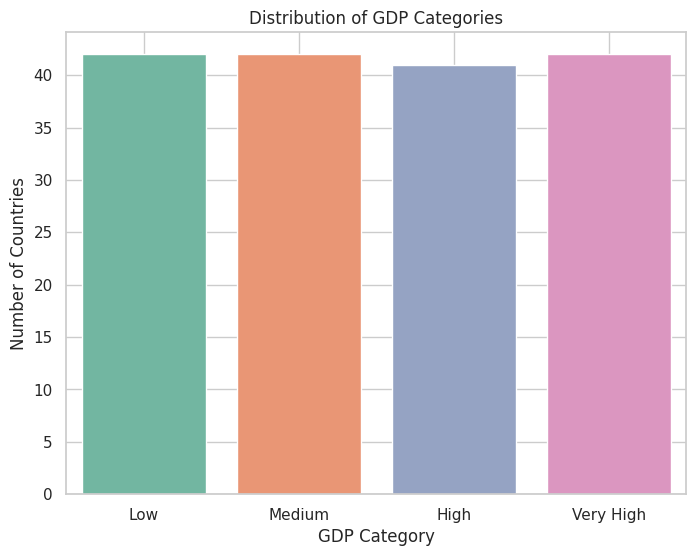

In [39]:
plt.figure(figsize=(8,6))

sns.countplot(

    x="GDP_Category",

    data=scaled_feature_df,

    palette="Set2"

)

plt.title("Distribution of GDP Categories")

plt.xlabel("GDP Category")

plt.ylabel("Number of Countries")

plt.grid(True)

plt.show()

# Selecting Input Features and Target Variable

The feature matrix (X) contains all predictor variables.

The target variable (y) contains the GDP categories.

In [40]:


X = scaled_feature_df.drop(

    columns=[

        "GDP_Category",

        "gdpp"

    ]

)


y = scaled_feature_df["GDP_Category"]

In [41]:
print("Feature Columns")

print()

print(X.columns)

Feature Columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'GDP_per_Income_Ratio',
       'Trade_Balance', 'Healthcare_Efficiency'],
      dtype='object')


# Splitting Dataset

The dataset is divided into training and testing sets.

Training Data : 80%

Testing Data : 20%

Random State : 42

In [43]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (133, 12)
Testing Features : (34, 12)
Training Labels : (133,)
Testing Labels : (34,)


# Logistic Regression

## Model Description

Logistic Regression is one of the most widely used supervised learning algorithms for classification.

Although its name contains "Regression", it is primarily used for classification problems.

Advantages:

- Fast
- Simple
- Easy to interpret
- Good baseline model

In [44]:
logistic_model = LogisticRegression(max_iter=1000,
    random_state=42

)
logistic_model.fit(
    X_train,
    y_train
)
print("Model Training Completed.")
y_pred_logistic = logistic_model.predict(
    X_test
)
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)
print("Accuracy :", round(accuracy,4))
precision = precision_score(
    y_test,
  y_pred_logistic,
    average="weighted"
)
print("Precision :", round(precision,4))
recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Recall :", round(recall,4))
f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"

)

print("F1 Score :", round(f1,4))
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Model Training Completed.
Accuracy : 0.7059
Precision : 0.7651
Recall : 0.7059
F1 Score : 0.6597
              precision    recall  f1-score   support

        High       0.56      0.62      0.59         8
         Low       0.73      1.00      0.84         8
      Medium       1.00      0.22      0.36         9
   Very High       0.75      1.00      0.86         9

    accuracy                           0.71        34
   macro avg       0.76      0.71      0.66        34
weighted avg       0.77      0.71      0.66        34



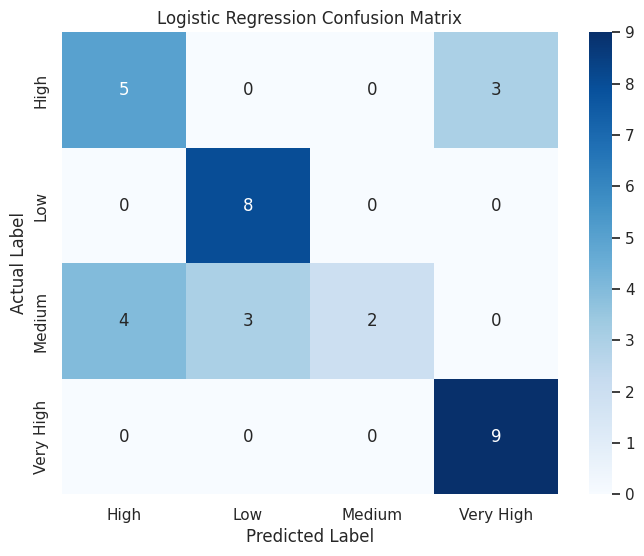

In [47]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

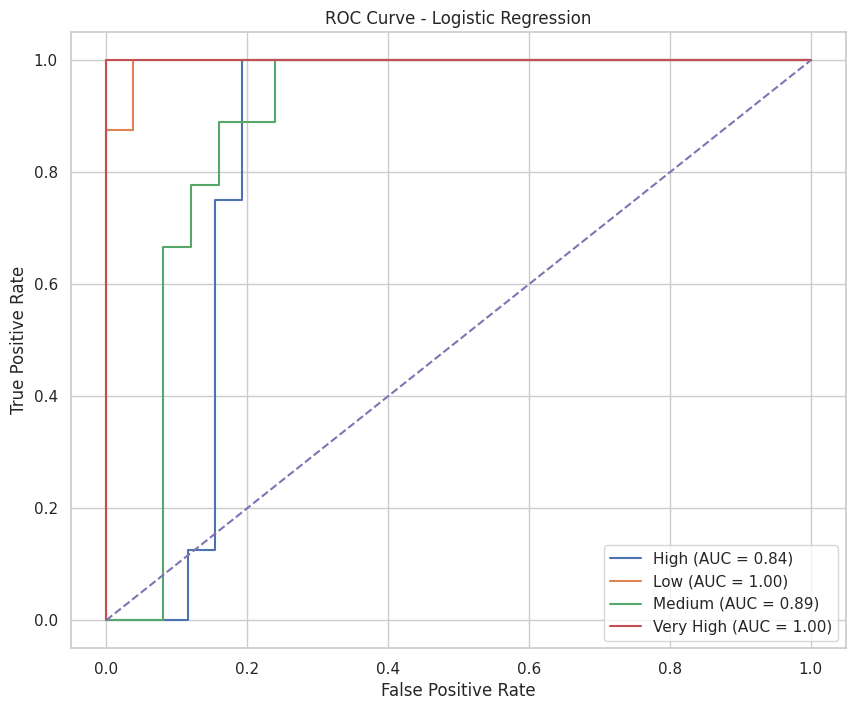

In [48]:

classes = logistic_model.classes_
y_test_binary = label_binarize(
    y_test,
    classes=classes
)

y_probability = logistic_model.predict_proba(
    X_test
)
plt.figure(figsize=(10,8))

for i in range(len(classes)):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, i],
        y_probability[:, i]
    )
    roc_auc = auc(
        false_positive_rate,
        true_positive_rate
    )
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{classes[i]} (AUC = {roc_auc:.2f})"
    )
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

# Decision Tree Classifier

## Model Description

A Decision Tree is a supervised machine learning algorithm that classifies data by learning a series of decision rules.

The model repeatedly splits the dataset into smaller subsets based on the feature that provides the highest information gain.

### Advantages

- Easy to understand
- Easy to visualize
- Handles non-linear relationships
- Requires very little data preprocessing

### Disadvantages

- Can easily overfit
- Sensitive to small changes in data
- Deep trees reduce generalization ability

In this section, we will train a Decision Tree Classifier and evaluate its performance.

In [49]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
print("Decision Tree Model Initialized Successfully.")
decision_tree_model.fit(
    X_train,
    y_train
)
print("Decision Tree Model Trained Successfully.")
y_pred_decision_tree = decision_tree_model.predict(
    X_test
)
print("Prediction Completed Successfully.")
comparison_df = pd.DataFrame({
    "Actual Category": y_test.values,
    "Predicted Category": y_pred_decision_tree
})
comparison_df.head(15)

decision_tree_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree
)

print("Decision Tree Accuracy")

print(round(decision_tree_accuracy,4))

decision_tree_precision = precision_score(
    y_test,
    y_pred_decision_tree,
    average="weighted"
)

print("Decision Tree Precision")

print(round(decision_tree_precision,4))

decision_tree_recall = recall_score(
    y_test,
    y_pred_decision_tree,
    average="weighted"
)

print("Decision Tree Recall")

print(round(decision_tree_recall,4))

decision_tree_f1 = f1_score(
    y_test,
    y_pred_decision_tree,
    average="weighted"
)
print("Decision Tree F1 Score")

print(round(decision_tree_f1,4))

decision_tree_report = classification_report(
    y_test,
    y_pred_decision_tree
)
print(decision_tree_report)

Decision Tree Model Initialized Successfully.
Decision Tree Model Trained Successfully.
Prediction Completed Successfully.
Decision Tree Accuracy
0.7353
Decision Tree Precision
0.741
Decision Tree Recall
0.7353
Decision Tree F1 Score
0.737
              precision    recall  f1-score   support

        High       0.56      0.62      0.59         8
         Low       0.88      0.88      0.88         8
      Medium       0.75      0.67      0.71         9
   Very High       0.78      0.78      0.78         9

    accuracy                           0.74        34
   macro avg       0.74      0.74      0.74        34
weighted avg       0.74      0.74      0.74        34



Confusion Matrix Generated Successfully.


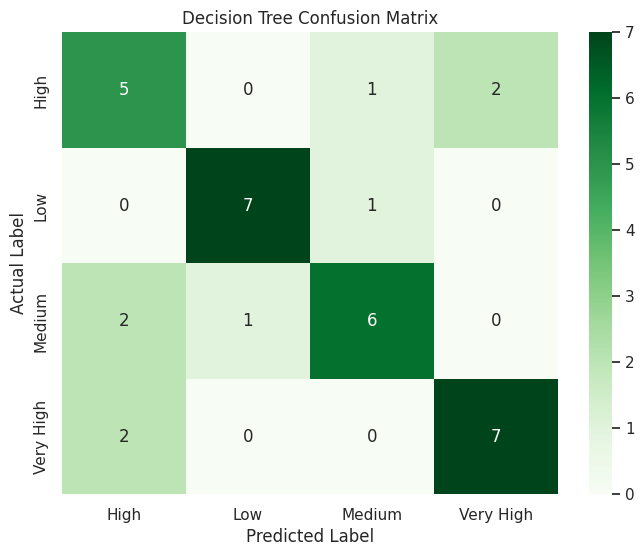

In [51]:
decision_tree_cm = confusion_matrix(
    y_test,
    y_pred_decision_tree
)

print("Confusion Matrix Generated Successfully.")
plt.figure(figsize=(8,6))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=decision_tree_model.classes_,
    yticklabels=decision_tree_model.classes_
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.grid(False)

plt.show()

# Random Forest Classifier

## Model Description

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Instead of relying on a single Decision Tree, Random Forest creates several trees using random subsets of data and features. The final prediction is made using majority voting.

### Advantages

- High prediction accuracy
- Reduces overfitting
- Handles large datasets
- Works well with nonlinear relationships
- Robust against noisy data

### Disadvantages

- More computationally expensive
- Less interpretable than a single Decision Tree

In this section, we will train a Random Forest model and evaluate its performance.

In [52]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=42
)

print("Random Forest Model Initialized Successfully.")
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully.")
y_pred_random_forest = random_forest_model.predict(
    X_test
)

print("Prediction Completed Successfully.")
comparison_rf = pd.DataFrame({
    "Actual Category": y_test.values,
    "Predicted Category": y_pred_random_forest
})

comparison_rf.head(15)
random_forest_accuracy = accuracy_score(
    y_test,
    y_pred_random_forest
)

print("Random Forest Accuracy")

print(round(random_forest_accuracy,4))
random_forest_precision = precision_score(
    y_test,
    y_pred_random_forest,
    average="weighted"
)

print("Random Forest Precision")

print(round(random_forest_precision,4))
random_forest_recall = recall_score(
    y_test,
    y_pred_random_forest,
    average="weighted"
)

print("Random Forest Recall")

print(round(random_forest_recall,4))
random_forest_f1 = f1_score(
    y_test,
    y_pred_random_forest,
    average="weighted"
)

print("Random Forest F1 Score")

print(round(random_forest_f1,4))
random_forest_report = classification_report(
    y_test,
    y_pred_random_forest
)

print(random_forest_report)

Random Forest Model Initialized Successfully.
Random Forest Model Trained Successfully.
Prediction Completed Successfully.
Random Forest Accuracy
0.8235
Random Forest Precision
0.8355
Random Forest Recall
0.8235
Random Forest F1 Score
0.8266
              precision    recall  f1-score   support

        High       0.67      0.75      0.71         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      0.89      0.84         9
   Very High       0.88      0.78      0.82         9

    accuracy                           0.82        34
   macro avg       0.84      0.82      0.83        34
weighted avg       0.84      0.82      0.83        34



# Confusion Matrix

## Random Forest Confusion Matrix

A Confusion Matrix compares the actual GDP category with the predicted GDP category.

It helps us identify:

- Correct classifications
- Incorrect classifications
- Frequently misclassified GDP categories

A perfect model will have all observations on the main diagonal.

Confusion Matrix Generated Successfully.


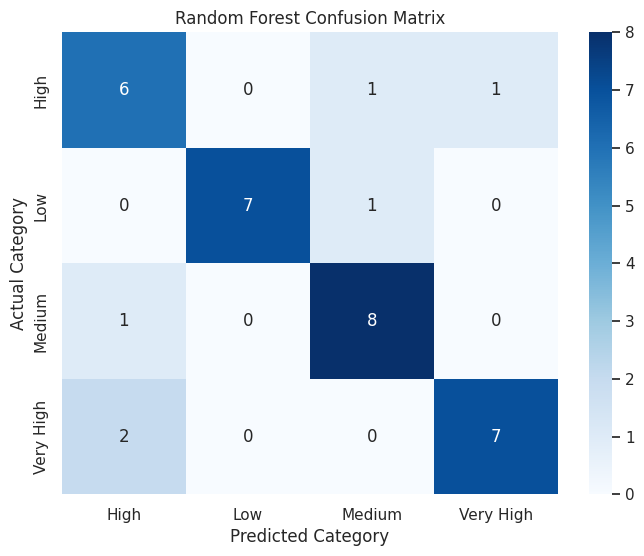

In [53]:
random_forest_cm = confusion_matrix(
    y_test,
    y_pred_random_forest
)

print("Confusion Matrix Generated Successfully.")
plt.figure(figsize=(8,6))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=random_forest_model.classes_,
    yticklabels=random_forest_model.classes_
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Category")

plt.ylabel("Actual Category")

plt.grid(False)

plt.show()

# XGBoost Classifier

## Model Description

Extreme Gradient Boosting (XGBoost) is one of the most powerful supervised machine learning algorithms based on Gradient Boosting.

Unlike Random Forest, which builds multiple independent trees, XGBoost builds trees sequentially. Each new tree attempts to correct the errors made by the previous trees.

XGBoost is widely used in machine learning competitions because of its high prediction accuracy and excellent generalization capability.

### Advantages

- High prediction accuracy
- Handles missing values efficiently
- Prevents overfitting using regularization
- Supports parallel computation
- Excellent for structured/tabular datasets

### Limitations

- Computationally expensive
- More parameters to tune
- Less interpretable than simpler models

In this section, we will train an XGBoost classifier to classify countries into GDP categories.

In [54]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
label_mapping = pd.DataFrame({

    "Original Label": target_encoder.classes_,

    "Encoded Label": range(len(target_encoder.classes_))

})

label_mapping

#Train
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded

)

print("Training Dataset Shape :", X_train_xgb.shape)
print("Testing Dataset Shape :", X_test_xgb.shape)

Training Dataset Shape : (133, 12)
Testing Dataset Shape : (34, 12)


In [55]:
xgb_model = XGBClassifier(

    objective="multi:softprob",

    num_class=4,

    n_estimators=100,

    learning_rate=0.10,

    max_depth=6,

    subsample=0.80,

    colsample_bytree=0.80,

    random_state=42,

    eval_metric="mlogloss"

)

print("XGBoost Model Initialized Successfully.")

XGBoost Model Initialized Successfully.


In [56]:
xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)
y_pred_xgb = xgb_model.predict(
    X_test_xgb
)
predicted_labels = target_encoder.inverse_transform(
    y_pred_xgb
)
actual_labels = target_encoder.inverse_transform(
    y_test_xgb
)
comparison_xgb = pd.DataFrame({

    "Actual GDP Category": actual_labels,

    "Predicted GDP Category": predicted_labels

})

comparison_xgb.head(15)

,Actual GDP Category,Predicted GDP Category
0,Medium,Medium
1,Low,Medium
2,Medium,Medium
3,Low,Low
4,Very High,Very High
5,Very High,Very High
6,Very High,High
7,Low,Low
8,High,Very High
9,High,High


In [57]:
xgb_accuracy = accuracy_score(
    y_test_xgb,
    y_pred_xgb
)
print("XGBoost Accuracy")
print(round(xgb_accuracy, 4))

xgb_precision = precision_score(
    y_test_xgb,
    y_pred_xgb,
    average="weighted"
)
print("XGBoost Precision")
print(round(xgb_precision, 4))

xgb_recall = recall_score(
    y_test_xgb,
    y_pred_xgb,
    average="weighted"
)
print("XGBoost Recall")
print(round(xgb_recall, 4))

xgb_f1 = f1_score(
    y_test_xgb,
    y_pred_xgb,
    average="weighted"
)
print("XGBoost F1 Score")
print(round(xgb_f1, 4))

xgb_report = classification_report(
    y_test_xgb,
    y_pred_xgb,
    target_names=target_encoder.classes_
)
print(xgb_report)
xgb_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1
    ]
})
xgb_results

XGBoost Accuracy
0.7941
XGBoost Precision
0.8002
XGBoost Recall
0.7941
XGBoost F1 Score
0.7958
              precision    recall  f1-score   support

        High       0.67      0.75      0.71         8
         Low       0.88      0.88      0.88         8
      Medium       0.78      0.78      0.78         9
   Very High       0.88      0.78      0.82         9

    accuracy                           0.79        34
   macro avg       0.80      0.80      0.80        34
weighted avg       0.80      0.79      0.80        34



,Metric,Score
0,Accuracy,0.794118
1,Precision,0.800245
2,Recall,0.794118
3,F1 Score,0.795848


# LightGBM Classifier

## Model Description

Light Gradient Boosting Machine (LightGBM) is a gradient boosting framework developed by Microsoft.

Unlike traditional Gradient Boosting algorithms, LightGBM grows trees leaf-wise instead of level-wise, making it significantly faster while maintaining high predictive performance.

LightGBM is widely used for structured/tabular datasets because of its:

- High Speed
- Low Memory Consumption
- Excellent Accuracy
- Efficient Handling of Large Datasets

In this section, we will train a LightGBM classifier to predict GDP categories.

In [58]:
from lightgbm import LGBMClassifier
lightgbm_model = LGBMClassifier(

    objective="multiclass",

    num_class=4,

    n_estimators=100,

    learning_rate=0.10,

    max_depth=6,

    random_state=42

)


In [59]:
lightgbm_model.fit(

    X_train_xgb,

    y_train_xgb

)
y_pred_lightgbm = lightgbm_model.predict(

    X_test_xgb

)
lightgbm_actual_labels = target_encoder.inverse_transform(

    y_test_xgb

)

lightgbm_predicted_labels = target_encoder.inverse_transform(

    y_pred_lightgbm
)
lightgbm_prediction_df = pd.DataFrame({

    "Actual GDP Category": lightgbm_actual_labels,

    "Predicted GDP Category": lightgbm_predicted_labels

})

lightgbm_prediction_df.head(15)
print("Total Predictions Made :")

print(len(lightgbm_predicted_labels))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 529
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 12
[LightGBM] [Info] Start training from score -1.393842
[LightGBM] [Info] Start training from score -1.363989
[LightGBM] [Info] Start training from score -1.393842
[LightGBM] [Info] Start training from score -1.393842
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

LightGBM Accuracy
0.7941
LightGBM Precision
0.8
LightGBM Recall
0.7941
LightGBM F1 Score
0.7955
              precision    recall  f1-score   support

        High       0.62      0.62      0.62         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      0.89      0.84         9
   Very High       0.78      0.78      0.78         9

    accuracy                           0.79        34
   macro avg       0.80      0.79      0.79        34
weighted avg       0.80      0.79      0.80        34



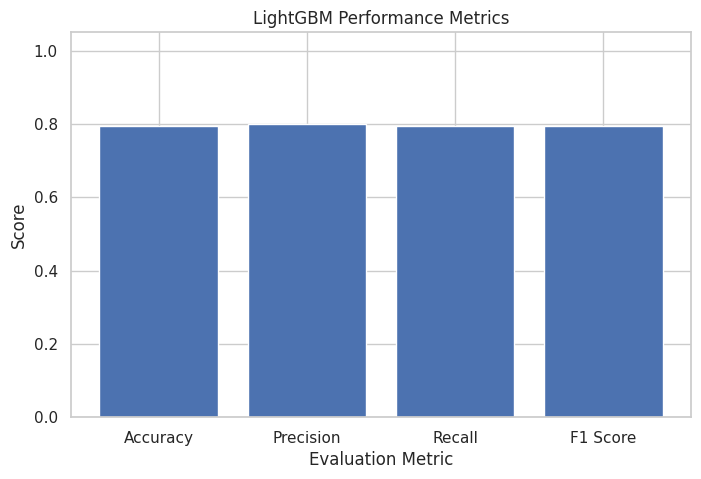

In [60]:

lightgbm_accuracy = accuracy_score(
    y_test_xgb,
    y_pred_lightgbm
)
print("LightGBM Accuracy")
print(round(lightgbm_accuracy, 4))

lightgbm_precision = precision_score(
    y_test_xgb,
    y_pred_lightgbm,
    average="weighted"
)
print("LightGBM Precision")
print(round(lightgbm_precision, 4))

lightgbm_recall = recall_score(
    y_test_xgb,
    y_pred_lightgbm,
    average="weighted"
)
print("LightGBM Recall")
print(round(lightgbm_recall, 4))

lightgbm_f1 = f1_score(
    y_test_xgb,
    y_pred_lightgbm,
    average="weighted"
)
print("LightGBM F1 Score")
print(round(lightgbm_f1, 4))

lightgbm_report = classification_report(
    y_test_xgb,
    y_pred_lightgbm,
    target_names=target_encoder.classes_
)
print(lightgbm_report)


lightgbm_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        lightgbm_accuracy,
        lightgbm_precision,
        lightgbm_recall,
        lightgbm_f1
    ]
})
lightgbm_results


plt.figure(figsize=(8,5))
plt.bar(
    lightgbm_results["Metric"],
    lightgbm_results["Score"]
)
plt.title("LightGBM Performance Metrics")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

# CatBoost Classifier

## Model Description

CatBoost (Categorical Boosting) is a gradient boosting algorithm developed by Yandex. It is specifically designed to handle categorical features efficiently while also delivering excellent performance on numerical datasets.

CatBoost builds decision trees sequentially, where each new tree attempts to correct the errors made by previous trees.

Unlike many boosting algorithms, CatBoost automatically reduces overfitting using Ordered Boosting and generally requires less hyperparameter tuning.

### Advantages

- Excellent prediction accuracy
- Fast training process
- Handles categorical variables effectively
- Reduces overfitting
- Minimal preprocessing required

### Limitations

- Training can be slower than LightGBM
- Large models require more memory
- More computationally expensive than Decision Trees

In this section, we will train a CatBoost Classifier to predict GDP categories.

In [62]:
!pip install catboost
from catboost import CatBoostClassifier
catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.10,
    depth=6,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_xgb,
    y_train_xgb
)
y_pred_catboost = catboost_model.predict(
    X_test_xgb
)
y_pred_catboost = np.array(
    y_pred_catboost
).flatten()
print("Prediction Shape")

print(y_pred_catboost.shape)
catboost_actual_labels = target_encoder.inverse_transform(
    y_test_xgb
)
catboost_predicted_labels = target_encoder.inverse_transform(
    y_pred_catboost.astype(int)
)
catboost_prediction_df = pd.DataFrame({
    "Actual GDP Category": catboost_actual_labels,
    "Predicted GDP Category": catboost_predicted_labels

})
catboost_prediction_df.head(15)
print("Total Predictions Generated")

print(len(catboost_predicted_labels))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00
Prediction Shape
(34,)
Total Predictions Generated
34


CatBoost Accuracy
0.7353
CatBoost Precision
0.741
CatBoost Recall
0.7353
CatBoost F1 Score
0.737
              precision    recall  f1-score   support

        High       0.56      0.62      0.59         8
         Low       0.88      0.88      0.88         8
      Medium       0.75      0.67      0.71         9
   Very High       0.78      0.78      0.78         9

    accuracy                           0.74        34
   macro avg       0.74      0.74      0.74        34
weighted avg       0.74      0.74      0.74        34



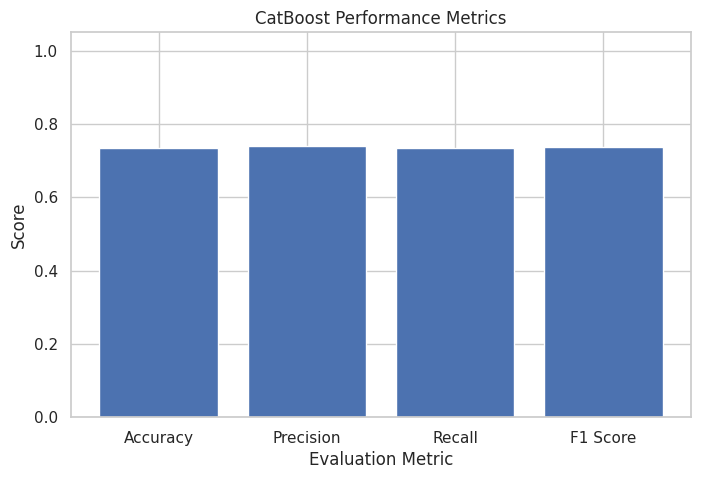

In [63]:
catboost_accuracy = accuracy_score(
    y_test_xgb,
    y_pred_catboost
)
print("CatBoost Accuracy")
print(round(catboost_accuracy, 4))

catboost_precision = precision_score(
    y_test_xgb,
    y_pred_catboost,
    average="weighted"
)
print("CatBoost Precision")
print(round(catboost_precision, 4))

catboost_recall = recall_score(
    y_test_xgb,
    y_pred_catboost,
    average="weighted"
)
print("CatBoost Recall")
print(round(catboost_recall, 4))

catboost_f1 = f1_score(
    y_test_xgb,
    y_pred_catboost,
    average="weighted"
)
print("CatBoost F1 Score")
print(round(catboost_f1, 4))

catboost_report = classification_report(
    y_test_xgb,
    y_pred_catboost,
    target_names=target_encoder.classes_
)
print(catboost_report)

catboost_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        catboost_accuracy,
        catboost_precision,
        catboost_recall,
        catboost_f1
    ]
})
catboost_results

plt.figure(figsize=(8,5))
plt.bar(
    catboost_results["Metric"],
    catboost_results["Score"]
)
plt.title("CatBoost Performance Metrics")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [64]:
comparison_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Accuracy":[
        accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgb_accuracy,
        lightgbm_accuracy,
        catboost_accuracy
    ],
    "Precision":[
        precision,
        decision_tree_precision,
        random_forest_precision,
        xgb_precision,
        lightgbm_precision,
        catboost_precision
    ],
    "Recall":[
        recall,
        decision_tree_recall,
        random_forest_recall,
        xgb_recall,
        lightgbm_recall,
        catboost_recall
    ],
    "F1 Score":[
        f1,
        decision_tree_f1,
        random_forest_f1,
        xgb_f1,
        lightgbm_f1,
        catboost_f1
    ]
})
comparison_df

best_model = comparison_df.iloc[0]
print("Best Classification Model")
print("--------------------------")
print(best_model)

Best Classification Model
--------------------------
Model        Logistic Regression
Accuracy                0.705882
Precision               0.765077
Recall                  0.705882
F1 Score                0.659698
Name: 0, dtype: object


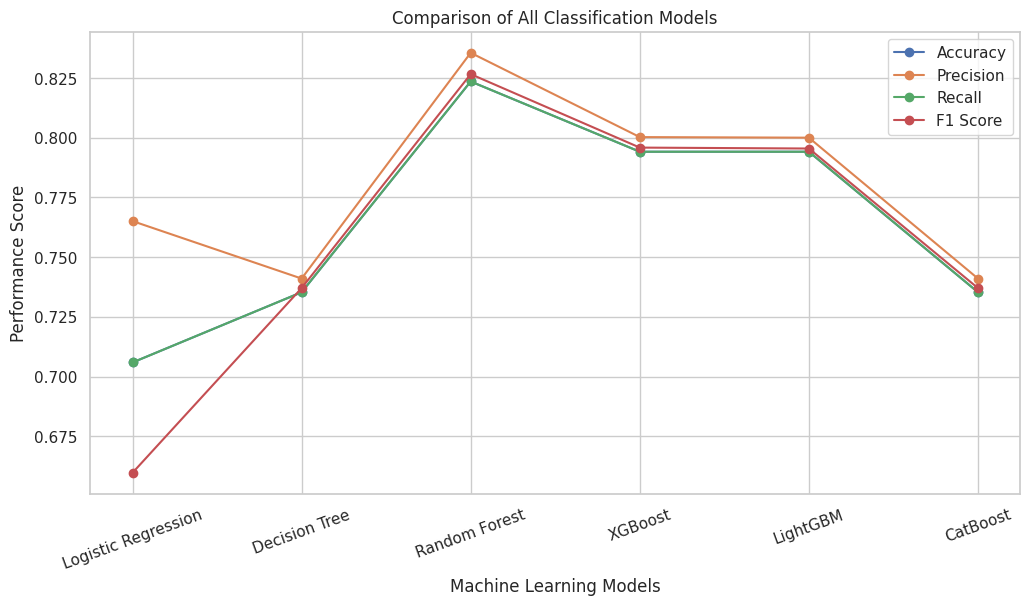

In [65]:
comparison_plot = comparison_df.set_index("Model")
comparison_plot.plot(
    figsize=(12,6),
    marker="o"
)
plt.title("Comparison of All Classification Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Performance Score")
plt.grid(True)
plt.xticks(rotation=20)
plt.show()

# PART : SHAP Explainability

## Introduction

Machine Learning models often make highly accurate predictions, but understanding **why** they make those predictions is equally important.

This is where **Explainable Artificial Intelligence (XAI)** comes into the picture.

One of the most widely used XAI techniques is **SHAP (SHapley Additive exPlanations)**.

SHAP explains the contribution of every feature towards the prediction made by a Machine Learning model.

In this section, we will use SHAP to explain the predictions generated by the Random Forest Classifier.

---

## Why SHAP?

SHAP helps answer questions like:

- Why was a country classified as High GDP?
- Which feature influenced the prediction the most?
- Which features had a positive contribution?
- Which features had a negative contribution?

Understanding these relationships improves model transparency and builds trust in Machine Learning systems.

In [66]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(
    random_forest_model
)
shap_values = explainer.shap_values(
    X_test
)
print("Number of Classes")

print(len(shap_values))
for index in range(len(shap_values)):
    print(
        "Class",
        index,
        "Shape:",
        shap_values[index].shape
    )

Number of Classes
34
Class 0 Shape: (12, 4)
Class 1 Shape: (12, 4)
Class 2 Shape: (12, 4)
Class 3 Shape: (12, 4)
Class 4 Shape: (12, 4)
Class 5 Shape: (12, 4)
Class 6 Shape: (12, 4)
Class 7 Shape: (12, 4)
Class 8 Shape: (12, 4)
Class 9 Shape: (12, 4)
Class 10 Shape: (12, 4)
Class 11 Shape: (12, 4)
Class 12 Shape: (12, 4)
Class 13 Shape: (12, 4)
Class 14 Shape: (12, 4)
Class 15 Shape: (12, 4)
Class 16 Shape: (12, 4)
Class 17 Shape: (12, 4)
Class 18 Shape: (12, 4)
Class 19 Shape: (12, 4)
Class 20 Shape: (12, 4)
Class 21 Shape: (12, 4)
Class 22 Shape: (12, 4)
Class 23 Shape: (12, 4)
Class 24 Shape: (12, 4)
Class 25 Shape: (12, 4)
Class 26 Shape: (12, 4)
Class 27 Shape: (12, 4)
Class 28 Shape: (12, 4)
Class 29 Shape: (12, 4)
Class 30 Shape: (12, 4)
Class 31 Shape: (12, 4)
Class 32 Shape: (12, 4)
Class 33 Shape: (12, 4)


# SHAP Summary Plot

The Summary Plot is the most important SHAP visualization.

It displays:

- Most influential features
- Positive impact
- Negative impact
- Overall feature importance

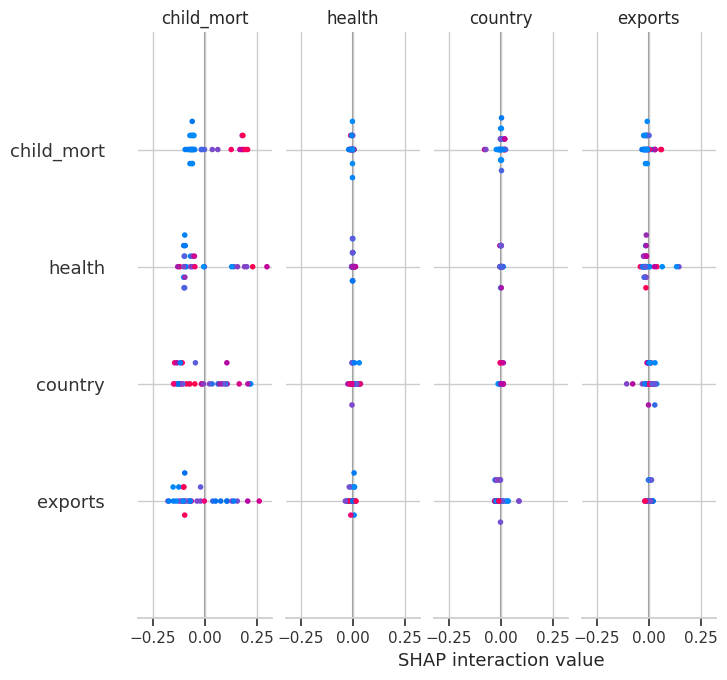

In [67]:

shap.summary_plot(

    shap_values,

    X_test,

    feature_names=X.columns

)

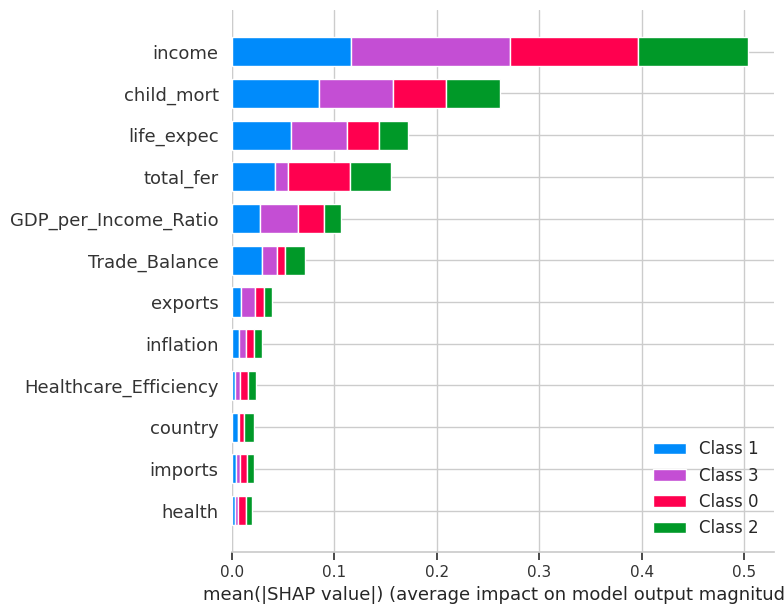

In [68]:
shap.summary_plot(

    shap_values,

    X_test,

    feature_names=X.columns,

    plot_type="bar"

)

# SHAP Waterfall Plot

The Waterfall Plot explains the contribution of each feature step by step for one prediction.

This visualization is one of the most interpretable SHAP plots.

Selected Sample Index : 0


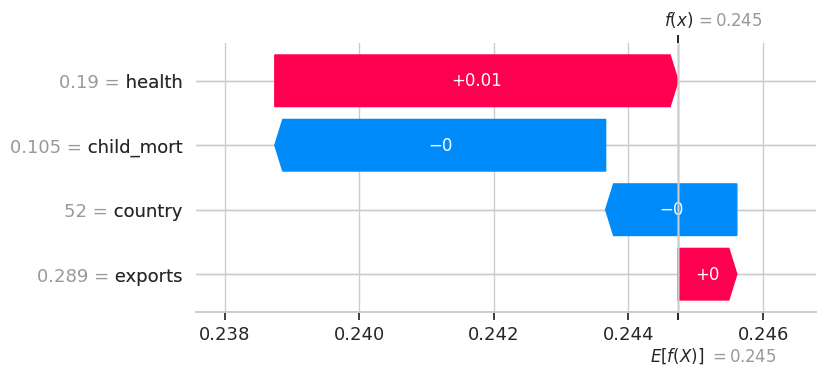

In [71]:
sample_index = 0

print("Selected Sample Index :", sample_index)
X_test.iloc[sample_index]
sample_explanation = shap.Explanation(
    values=shap_values[0][sample_index],
    base_values=explainer.expected_value[0],
    data=X_test.iloc[sample_index],
    feature_names=X.columns
)
shap.plots.waterfall(

    sample_explanation,

    max_display=15

)

# PART : Customer Segmentation using Machine Learning

## Introduction

Customer Segmentation is one of the most widely used applications of Unsupervised Machine Learning.

Instead of predicting a target variable, clustering algorithms group similar observations together based on their characteristics.

In this project, each country acts as a customer, and socio-economic indicators are used to identify groups of countries with similar development patterns.

The objectives of this section are:

- Prepare the dataset for clustering.
- Standardize numerical features.
- Reduce dimensionality using Principal Component Analysis (PCA).
- Visualize the transformed dataset.
- Prepare the data for K-Means and DBSCAN clustering.

In [72]:
clustering_df = feature_df.copy()
print("Shape of Dataset")
print(clustering_df.shape)

Shape of Dataset
(167, 13)


In [73]:
clustering_df = clustering_df.drop(

    columns=["country"]

)

print("Updated Shape")

print(clustering_df.shape)
clustering_df.head()
numerical_features = clustering_df.columns

print("Numerical Features")

print()

for feature in numerical_features:
    print(feature)
print(clustering_df.isnull().sum())

Updated Shape
(167, 12)
Numerical Features

child_mort
exports
health
imports
income
inflation
life_expec
total_fer
gdpp
GDP_per_Income_Ratio
Trade_Balance
Healthcare_Efficiency
child_mort               0
exports                  0
health                   0
imports                  0
income                   0
inflation                0
life_expec               0
total_fer                0
gdpp                     0
GDP_per_Income_Ratio     0
Trade_Balance            0
Healthcare_Efficiency    0
dtype: int64


In [74]:
standard_scaler = StandardScaler()
scaled_clustering_data = standard_scaler.fit_transform(

    clustering_df

)

scaled_clustering_df = pd.DataFrame(

    scaled_clustering_data,

    columns=clustering_df.columns

)

scaled_clustering_df.head()

scaled_clustering_df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,GDP_per_Income_Ratio,Trade_Balance,Healthcare_Efficiency
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70,-1.23,-3.59,-1.36
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64,-0.67,-0.48,-0.63
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45,-0.34,0.05,-0.20
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06,0.26,0.51,0.26
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04,4.72,2.39,5.34


# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of using all variables directly, PCA transforms the dataset into a smaller number of components while preserving as much information as possible.

Benefits of PCA include:

- Reduced dimensionality
- Faster clustering
- Better visualization
- Reduced multicollinearity

In [78]:
pca = PCA()


In [80]:

pca.fit(
    scaled_clustering_df
)
print("PCA Fitted Successfully.")
explained_variance = pca.explained_variance_ratio_
print(explained_variance)
variance_table = pd.DataFrame({
    "Principal Component":
    np.arange(
        1,
        len(explained_variance)+1
    ),
    "Explained Variance":
    explained_variance
})
variance_table

PCA Fitted Successfully.
[0.39302357 0.20529348 0.13227879 0.10453404 0.06315905 0.03822899
 0.02765592 0.01633572 0.0086856  0.00724504 0.00355978 0.        ]


,Principal Component,Explained Variance
0,1,0.393024
1,2,0.205293
2,3,0.132279
3,4,0.104534
4,5,0.063159
5,6,0.038229
6,7,0.027656
7,8,0.016336
8,9,0.008686
9,10,0.007245


In [81]:

variance_table["Cumulative Variance"] = variance_table[

    "Explained Variance"

].cumsum()

variance_table

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.393024,0.393024
1,2,0.205293,0.598317
2,3,0.132279,0.730596
3,4,0.104534,0.835130
4,5,0.063159,0.898289
5,6,0.038229,0.936518
6,7,0.027656,0.964174
7,8,0.016336,0.980510
8,9,0.008686,0.989195
9,10,0.007245,0.996440


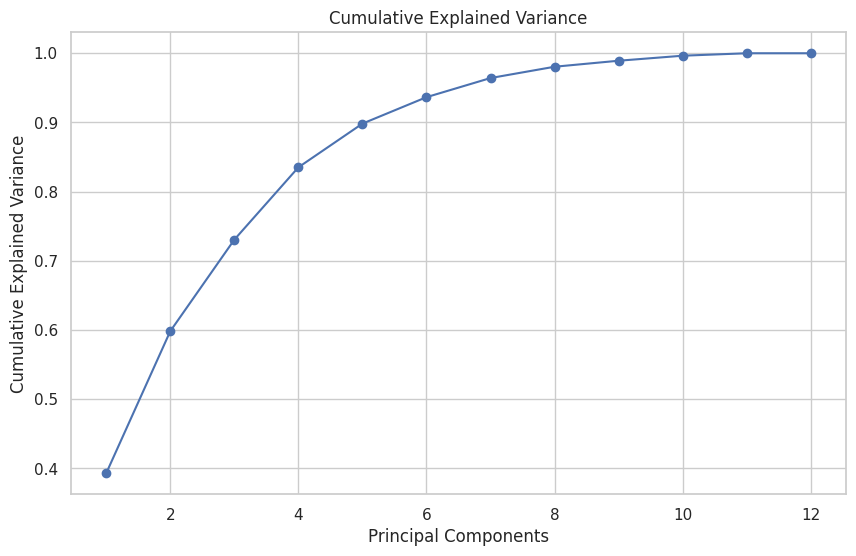

In [82]:
plt.figure(figsize=(10,6))
plt.plot(
    variance_table["Principal Component"],
    variance_table["Cumulative Variance"],
    marker="o"
)
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

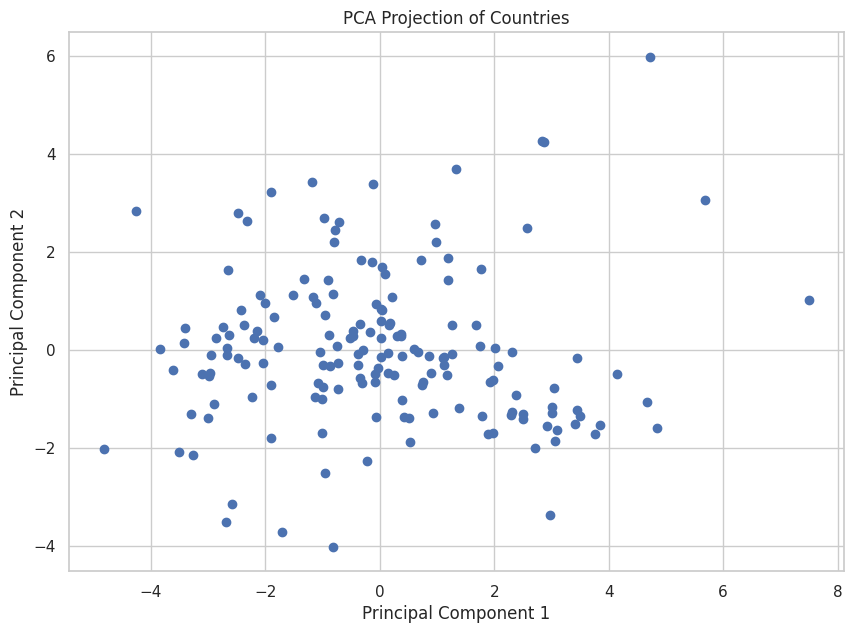

Original Shape
(167, 12)

PCA Shape
(167, 2)


In [84]:
pca = PCA(
    n_components=2,
    random_state=42
)
principal_components = pca.fit_transform(
    scaled_clustering_df
)
pca_df = pd.DataFrame(
    principal_components,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)
pca_df.head()

plt.figure(figsize=(10,7))
plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"]
)
plt.title("PCA Projection of Countries")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

print("Original Shape")
print(clustering_df.shape)
print()
print("PCA Shape")
print(pca_df.shape)

# PART : K-Means Clustering

## Introduction

K-Means is one of the most widely used unsupervised machine learning algorithms.

The objective of K-Means is to partition observations into **K clusters**, where observations within the same cluster are similar while observations from different clusters are dissimilar.

In this section, we will:

- Determine the optimal number of clusters
- Apply K-Means clustering
- Evaluate clustering performance
- Visualize clusters
- Analyze cluster statistics
- Interpret each cluster

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Finding the Optimal Number of Clusters

The Elbow Method helps determine the optimal number of clusters.

The algorithm is executed multiple times using different values of K.

For every K value, the Within Cluster Sum of Squares (WCSS) is calculated.

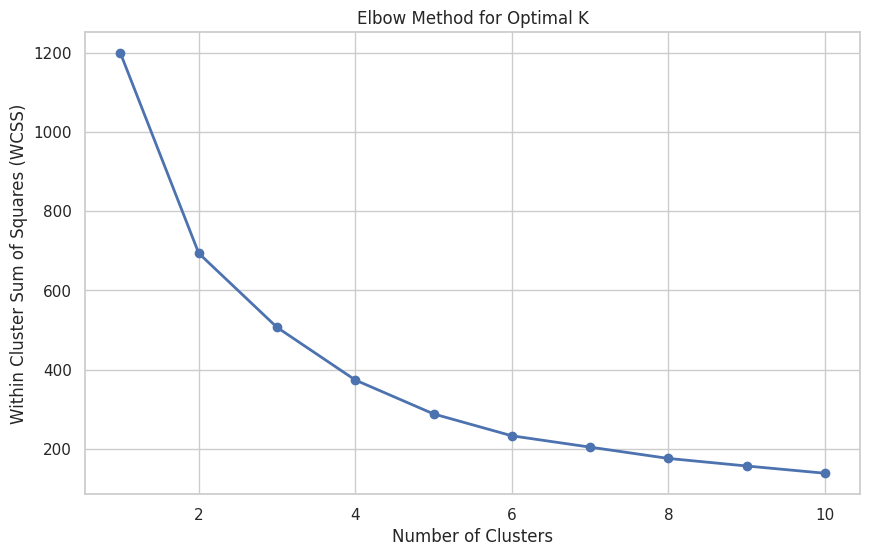

In [86]:
wcss = []
cluster_range = range(1,11)
for k in cluster_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(pca_df)
    wcss.append(model.inertia_)

elbow_table = pd.DataFrame({
    "Number of Clusters": list(cluster_range),
    "WCSS": wcss
})
elbow_table

plt.figure(figsize=(10,6))
plt.plot(
    cluster_range,
    wcss,
    marker="o",
    linewidth=2
)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Within Cluster Sum of Squares (WCSS)")
plt.grid(True)
plt.show()

K-Means Model Trained Successfully.


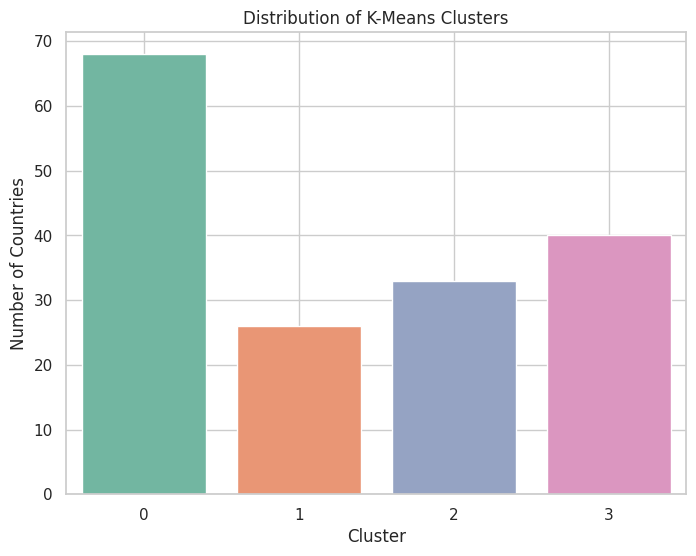

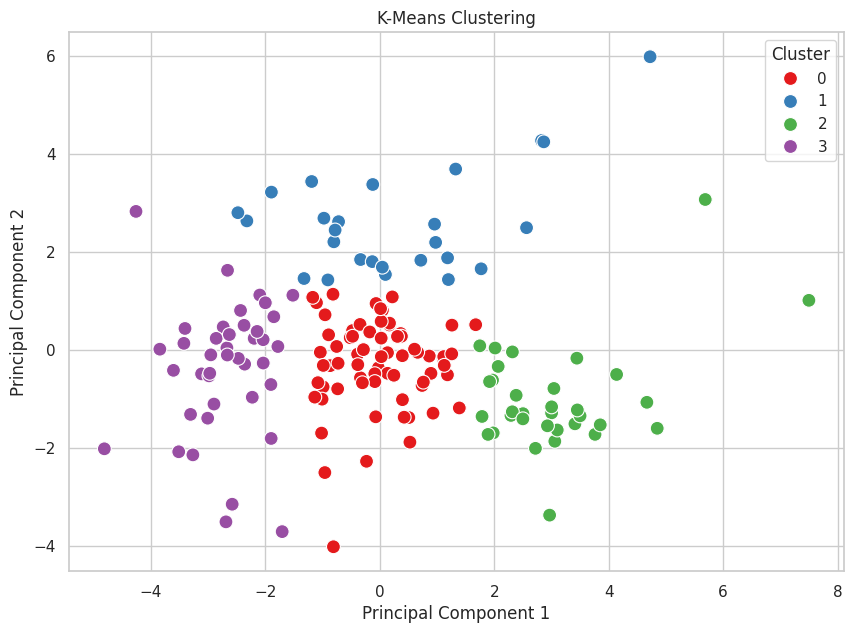

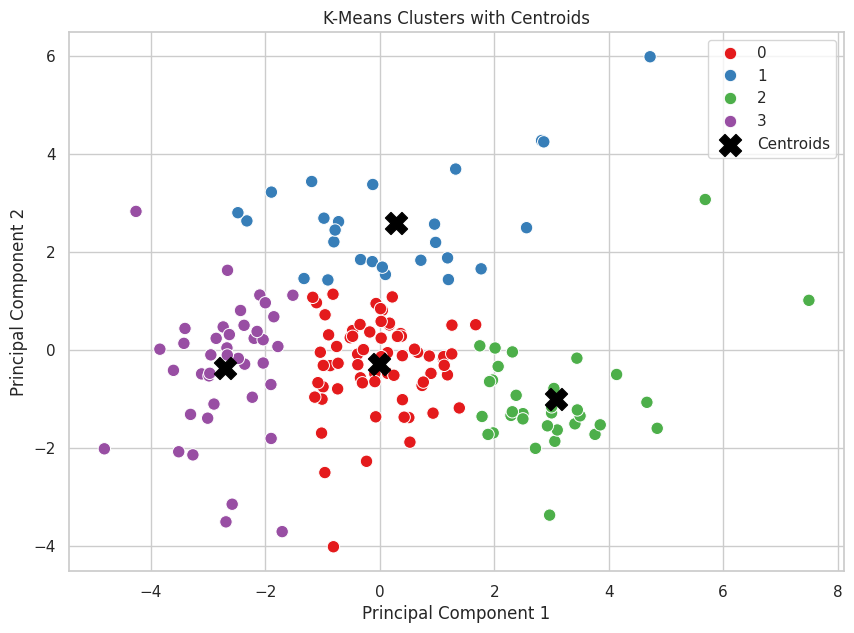

In [87]:

kmeans_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_model.fit(
    pca_df
)

print("K-Means Model Trained Successfully.")
cluster_labels = kmeans_model.predict(
    pca_df
)

pca_df["Cluster"] = cluster_labels
pca_df.head()

cluster_counts = pca_df["Cluster"].value_counts()
cluster_counts

plt.figure(figsize=(8,6))
sns.countplot(
    x="Cluster",
    data=pca_df,
    palette="Set2")
plt.title("Distribution of K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Cluster",
    palette="Set1",
    s=100
)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()
centroids = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)
centroids

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Cluster",
    palette="Set1",
    s=80
)
plt.scatter(
    centroids["Principal Component 1"],
    centroids["Principal Component 2"],
    marker="X",
    s=250,
    c="black",
    label="Centroids"
)
plt.title("K-Means Clusters with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend()
plt.show()

# Evaluating Cluster Quality

Silhouette Score measures how well-separated the clusters are.

Range:

- +1 → Excellent Clustering
- 0 → Overlapping Clusters
- -1 → Poor Clustering

Silhouette Score
0.4007


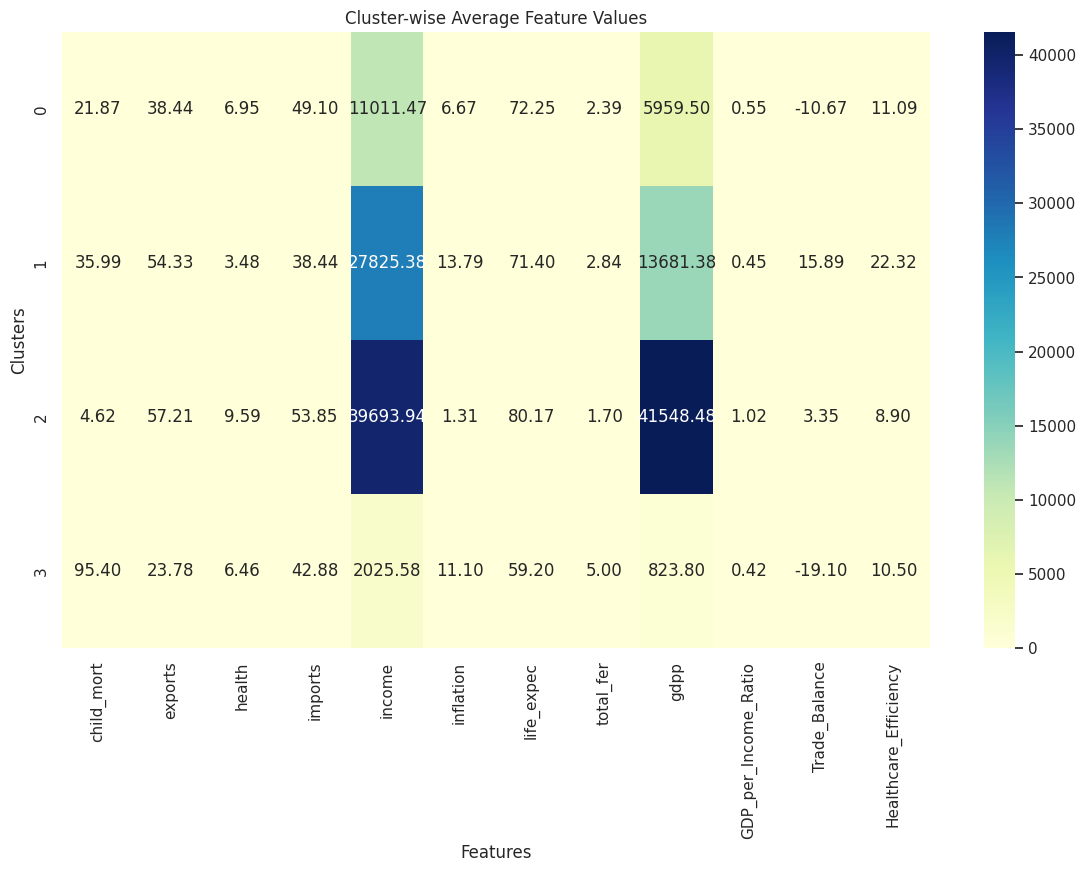

In [89]:

silhouette = silhouette_score(
    pca_df.drop(columns=["Cluster"]),
    cluster_labels
)
print("Silhouette Score")
print(round(silhouette,4))

cluster_analysis = feature_df.copy()
cluster_analysis["Cluster"] = cluster_labels
cluster_analysis.head()

cluster_summary = cluster_analysis.groupby(
    "Cluster"
).mean(numeric_only=True)
cluster_summary

plt.figure(figsize=(14,8))
sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Cluster-wise Average Feature Values")
plt.xlabel("Features")
plt.ylabel("Clusters")
plt.show()

# PART : Density-Based Clustering using DBSCAN

## Introduction

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised machine learning algorithm that groups observations based on density rather than distance.

Unlike K-Means, DBSCAN:

- Does not require specifying the number of clusters.
- Can identify noise (outliers).
- Detects clusters of arbitrary shapes.
- Works well when clusters are not spherical.

In this section, we will:

- Train a DBSCAN model.
- Identify clusters and noise points.
- Visualize the resulting clusters.
- Compare DBSCAN with K-Means.
- Recommend the best clustering algorithm.

# Initialize DBSCAN Model

DBSCAN requires two important parameters:

- eps
- min_samples

These parameters determine the density threshold for forming clusters.

DBSCAN Training Completed.
[ 0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Total Clusters
2
Noise Points
26


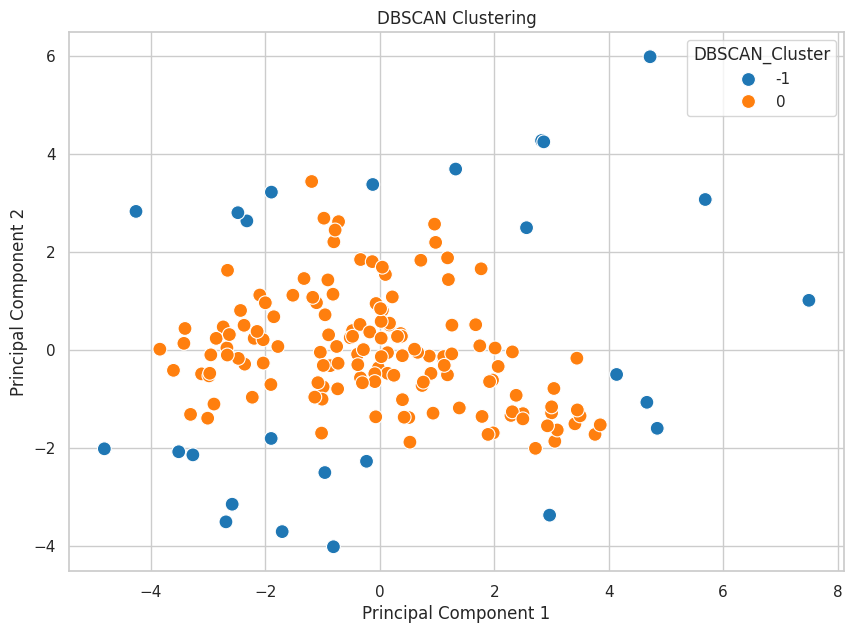

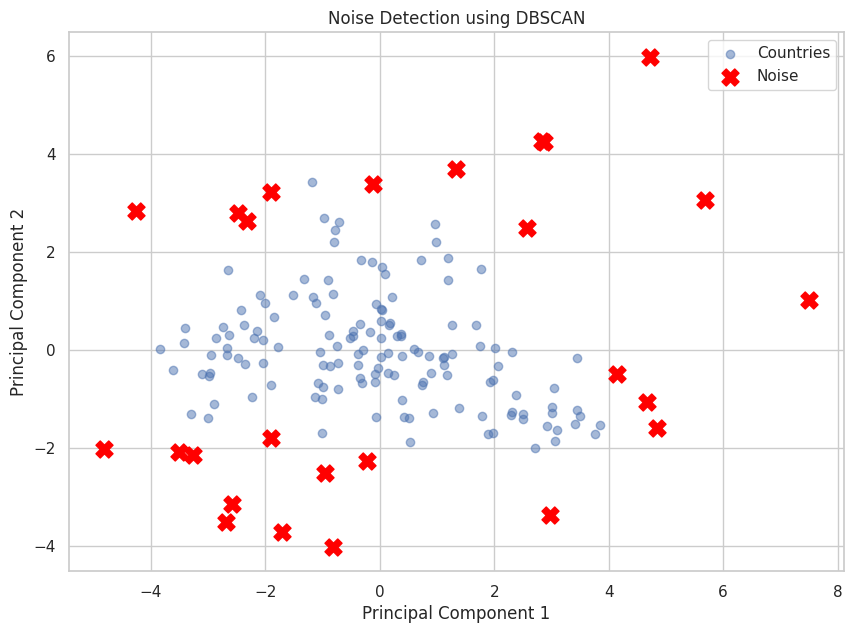

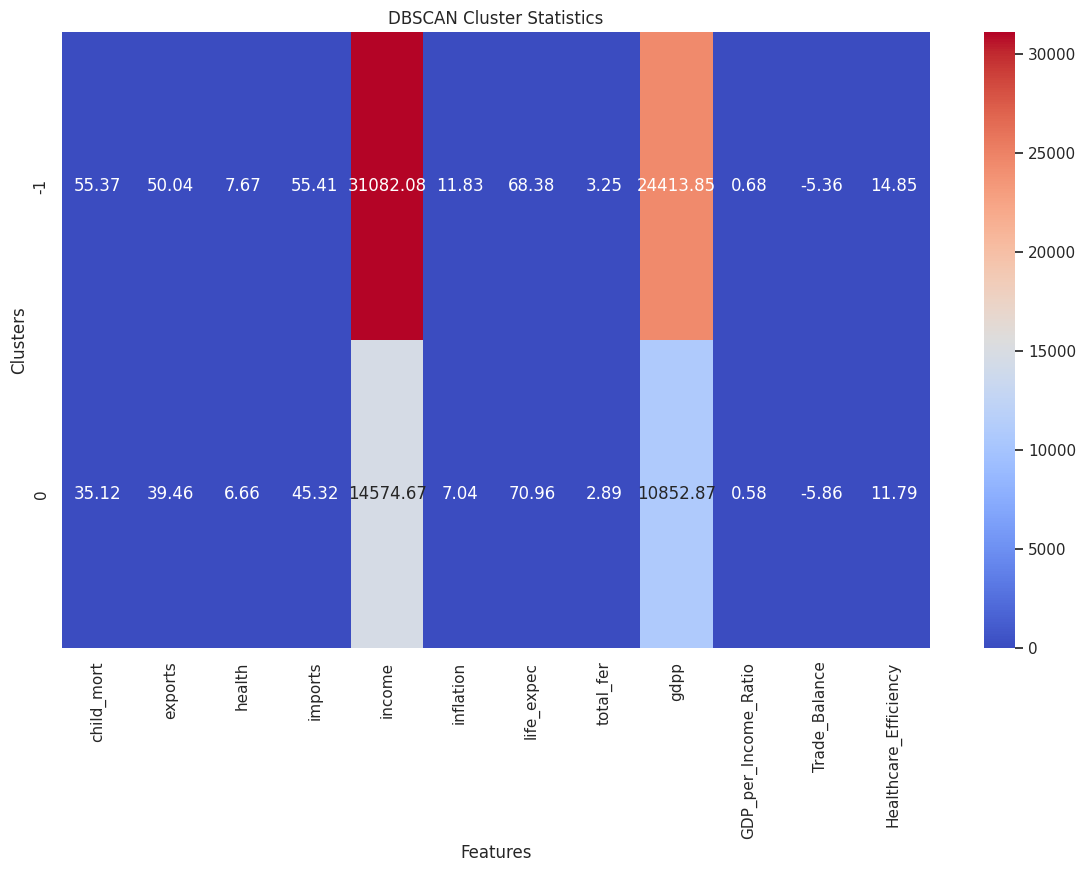

,Criteria,K-Means,DBSCAN
0,Need Number of Clusters,Yes,No
1,Handles Noise,No,Yes
2,Cluster Shape,Spherical,Arbitrary
3,Sensitive to Outliers,Yes,No
4,Training Speed,Fast,Moderate


In [91]:
from sklearn.cluster import DBSCAN
dbscan_model = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_model.fit(
    pca_df.drop(columns=["Cluster"])
)
print("DBSCAN Training Completed.")

dbscan_labels = dbscan_model.labels_
print(dbscan_labels[:20])

dbscan_df = pca_df.copy()
dbscan_df["DBSCAN_Cluster"] = dbscan_labels
dbscan_df.head()

number_of_clusters = len(
    set(dbscan_labels)
)
print("Total Clusters")
print(number_of_clusters)

noise_points = list(dbscan_labels).count(-1)
print("Noise Points")
print(noise_points)

dbscan_df["DBSCAN_Cluster"].value_counts()

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=dbscan_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=100
)
plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

noise_data = dbscan_df[
    dbscan_df["DBSCAN_Cluster"]==-1
]
plt.figure(figsize=(10,7))
plt.scatter(
    dbscan_df["Principal Component 1"],
    dbscan_df["Principal Component 2"],
    alpha=0.5,
    label="Countries"
)
plt.scatter(
    noise_data["Principal Component 1"],
    noise_data["Principal Component 2"],
    s=150,
    marker="X",
    color="red",
    label="Noise"
)
plt.title("Noise Detection using DBSCAN")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend()
plt.show()

dbscan_analysis = feature_df.copy()
dbscan_analysis["DBSCAN_Cluster"] = dbscan_labels

dbscan_summary = dbscan_analysis.groupby(
    "DBSCAN_Cluster"
).mean(numeric_only=True)
dbscan_summary

plt.figure(figsize=(14,8))
sns.heatmap(
    dbscan_summary,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("DBSCAN Cluster Statistics")
plt.xlabel("Features")
plt.ylabel("Clusters")
plt.show()
comparison_cluster = pd.DataFrame({
    "Criteria":[
        "Need Number of Clusters",
        "Handles Noise",
        "Cluster Shape",
        "Sensitive to Outliers",
        "Training Speed"
    ],
    "K-Means":[
        "Yes",
        "No",
        "Spherical",
        "Yes",
        "Fast"
    ],
    "DBSCAN":[
        "No",
        "Yes",
        "Arbitrary",
        "No",
        "Moderate"
    ]
})
comparison_cluster